<a href="https://mir-note-by-andrew.vercel.app/" style="display:inline-flex;align-items:center;gap:6px;text-decoration:none;font-family:'Inter',sans-serif;font-size:0.82rem;font-weight:500;color:#c96442;background:#fef6f2;border:1px solid #f0d4c8;border-radius:8px;padding:6px 12px;margin-bottom:8px;">&#8592; Home</a>

# Zero Crossing Rate

In [5]:
import IPython.display as ipd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy

**Zero Crossing Rate** simply represents how many times the signal crosses the horizontal axes.

In [6]:
fp = "simple_loop.wav"
x, sr = librosa.load(fp)

c:\Users\choyo\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
ipd.Audio(x, rate = sr)

Text(0, 0.5, 'Amplitude')

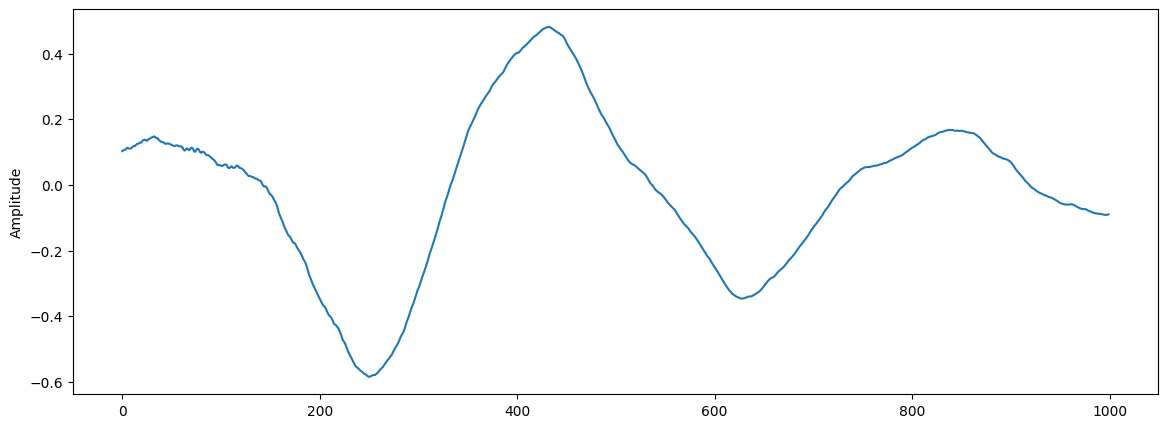

In [8]:
# we are zooming in now. 
n0 = 6500
n1 = 7500
plt.figure(figsize=(14,5))
plt.plot(x[n0:n1])
plt.ylabel("Amplitude")

In [ ]:
zero_crossings = librosa.zero_crossings(x[n0:n1], pad = False)

When we calcualte the zero_crossing rate in librosa, we need to calcualte two adjacent points. x[0] and x[1] and compare if the signal flipped from positive to negative or not. HOWEVER, for x[0], since there is nothing else to compare, it creates the fake neighbor to compare against. Like the fake neighbor before x[0].

**What's the point of doing it?**

Well, the output audio feature will have exactly same shape no matter what. For example, if we implment (44100, ), then it will output the (44100, ). Then what is the point of no-padding? It does not create the FAKE value. The padding might accidentally cause the "false positive" at the start of the array. 

In [10]:
zero_crossings.shape

(1000,)

Now I understood what is zero_crossing. 
Now, what is **Zero Crossing Rate** and how is it calcualted? 
$$ZCR = \frac{\text{number of zero crossings}}{number of samples in the frame}$$

For example, if Fram length = 1000 samples. 
Zero crossings = 20. 
Then the zero_crossing rate is 20/1000 = 0.02

5
(1, 97)


Text(0, 0.5, 'Zero crossing rate')

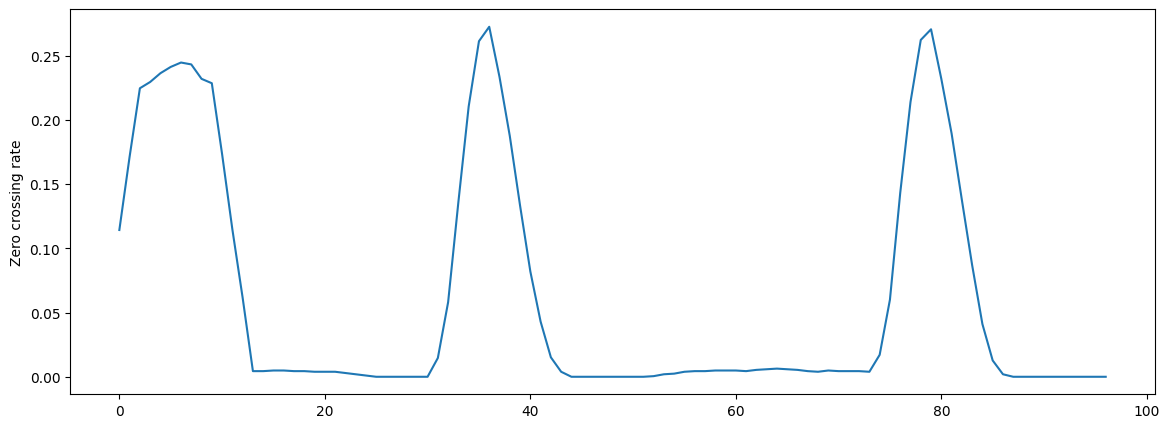

In [ ]:
print(sum(zero_crossings))
# what is sum doing here.
# zero_crossings --> [F, F, F, T, T]
# then sum will add up everythign saying T and output the value. 

zcrs = librosa.feature.zero_crossing_rate(x)
# I want to calculate the zero_crossing rate then, use this function
print(zcrs.shape)

plt.figure(figsize=(14,5))
plt.plot(zcrs[0])
plt.ylabel("Zero crossing rate")

#High zero crossing rate --> The sound graph wiggles a lot = high pitch
#Low zero crossing rate --> The sound graph does not wiggle = Low pitch